In [1]:
print("setup works")

setup works


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Pull FTSE 100 index data
ftse = yf.download("^FTSE", start="2015-01-01", end="2026-08-01")
ftse.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,
2015-01-02,6547.799805,6607.899902,6510.600098,6566.100098,367562200
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200


In [3]:
# Flattening the MultiIndex columns yfinance outputs
ftse.columns = ftse.columns.get_level_values(0)
ftse.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,6547.799805,6607.899902,6510.600098,6566.100098,367562200
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200


In [4]:
# Pulling S&P 500 index data
sp500 = yf.download("^GSPC", start="2015-01-01", end="2026-08-01")
sp500.columns = sp500.columns.get_level_values(0)
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [5]:
print("FTSE shape:", ftse.shape)
print("FTSE date range:", ftse.index.min(), "to", ftse.index.max())
print("Missing values in FTSE:\n", ftse.isnull().sum())

print("\nS&P 500 shape:", sp500.shape)
print("S&P 500 date range:", sp500.index.min(), "to", sp500.index.max())
print("Missing values in S&P 500:\n", sp500.isnull().sum())

FTSE shape: (2925, 5)
FTSE date range: 2015-01-02 00:00:00 to 2026-07-31 00:00:00
Missing values in FTSE:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

S&P 500 shape: (2911, 5)
S&P 500 date range: 2015-01-02 00:00:00 to 2026-07-31 00:00:00
Missing values in S&P 500:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


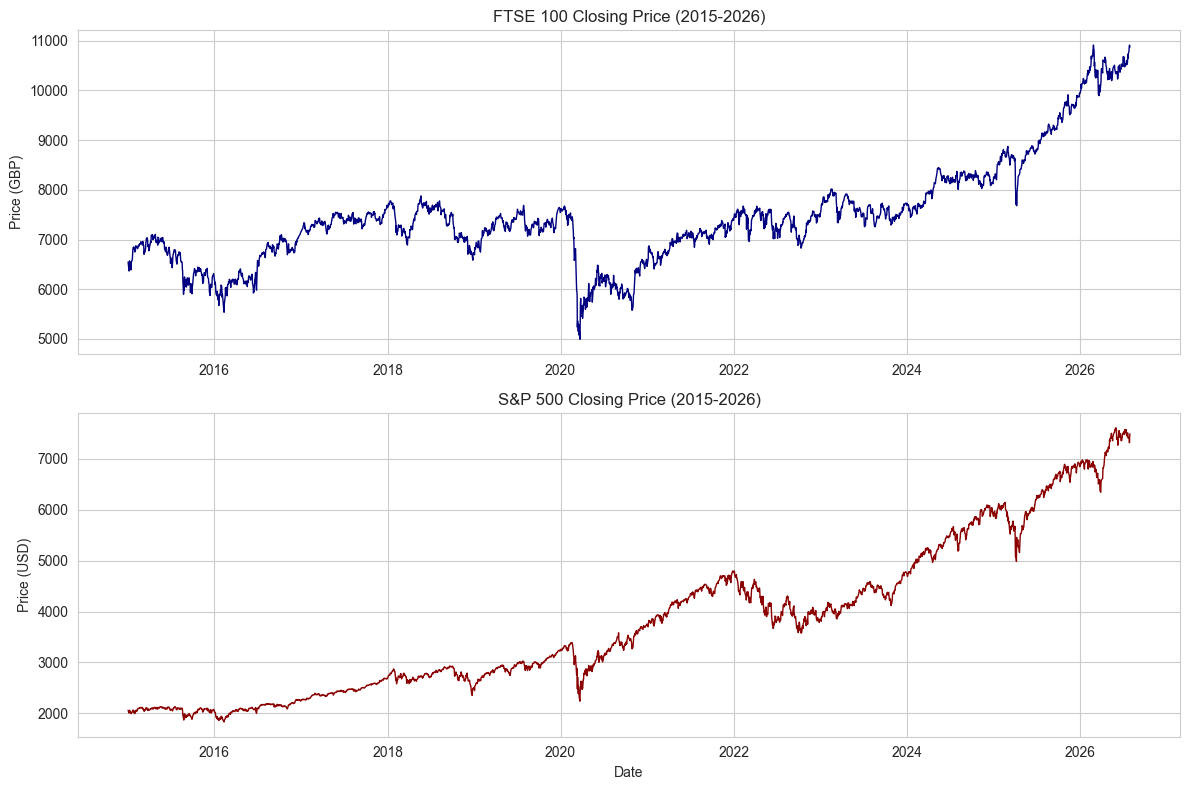

In [7]:
#visualizing the price series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ftse.index, ftse['Close'], color='navy', linewidth=1)
axes[0].set_title('FTSE 100 Closing Price (2015-2026)')
axes[0].set_ylabel('Price (GBP)')

axes[1].plot(sp500.index, sp500['Close'], color='darkred', linewidth=1)
axes[1].set_title('S&P 500 Closing Price (2015-2026)')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()